<a href="https://colab.research.google.com/github/Amna2327/DiffusionRec_Research/blob/main/DiffusionRec_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setting up repo and dataset


**Loading models and validation data from drive**

In [1]:
!pip install -U gdown  # older versions have known folder-download bugs
!gdown --folder https://drive.google.com/drive/folders/1qQMBSujyAGT1kQeZqWeafhYgDvcVH-6S

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Retrieving folder contents
Processing file 1f-pFHfsltfCupFh7cvMX2LW09cmLqAGp ckpt.pt
Processing file 1fN4gqHpMsBVcF1Q7pasalFa1X_BO5eJb ema_ckpt.pt
Processing file 1olbGBvnWmDZaJd400NLDjp0GKNdaL-s1 optim.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1f-pFHfsltfCupFh7cvMX2LW09cmLqAGp
From (redirected): https://drive.google.com/uc?id=1f-pFHfsltfCupFh7cvMX2LW09cmLqAGp&confirm=t&uuid=01d3beb5-8708-414f-899b-4ac4531cc284
To: /content/models/ckpt.pt
100% 678M/678M [00:13<00:00, 51.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1fN4gqHpMsBVcF1Q7pasalFa1X_BO5eJb
From (redirected): https://drive.google.com/uc?id=1fN4gqHpMsBVcF1Q7pasalFa1X_BO5eJb&confirm=t&uuid=beaecddb-4f32-48fa-8d81-4480d7bbf201
To: /con

**Checking size and structure**


In [2]:
!ls -la models/
!du -sh models/*
!ls -la

total 2631356
drwxr-xr-x 2 root root       4096 Jul 30 04:36 .
drwxr-xr-x 1 root root       4096 Jul 30 04:36 ..
-rw------- 1 root root  678075897 Apr 22 08:26 ckpt.pt
-rw------- 1 root root  678106925 Apr 22 06:22 ema_ckpt.pt
-rw------- 1 root root 1338299541 Apr 22 06:25 optim.pt
647M	models/ckpt.pt
647M	models/ema_ckpt.pt
1.3G	models/optim.pt
total 20
drwxr-xr-x 1 root root 4096 Jul 30 04:36 .
drwxr-xr-x 1 root root 4096 Jul 30 04:34 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config
drwxr-xr-x 2 root root 4096 Jul 30 04:36 models
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data


**Get and unzip val data**

In [3]:
!gdown https://drive.google.com/file/d/1POpevOJlxMfA33zkohU7G0ZBxJBy_yVd/view?usp=drive_link
!unzip -q val.zip -d ./val

Downloading...
From (original): https://drive.google.com/uc?id=1POpevOJlxMfA33zkohU7G0ZBxJBy_yVd
From (redirected): https://drive.google.com/uc?id=1POpevOJlxMfA33zkohU7G0ZBxJBy_yVd&confirm=t&uuid=92536446-5b1a-4b23-b175-a0cc361255a1
To: /content/val.zip
100% 363M/363M [00:04<00:00, 80.4MB/s]


**Confirming val contents**

In [4]:
!ls -la val/val

total 720
drwxrwxr-x 3 root root   4096 Sep  5  2023 .
drwxr-xr-x 3 root root   4096 Jul 30 04:38 ..
drwxrwxr-x 2 root root 327680 Feb 11  2022 images
-rw-rw-r-- 1 root root 393449 Sep  5  2023 val_gt.txt


**Cloning repo**

In [5]:
!git clone https://github.com/Amna2327/DiffusionRec_Research.git
%cd DiffusionRec_Research

Cloning into 'DiffusionRec_Research'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 135 (delta 52), reused 114 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 18.18 MiB | 36.64 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/DiffusionRec_Research


**Installing requirements**

In [6]:
!pip install -r requirements_linux.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Creation of parent directories to put models and val data**

In [1]:
!mkdir -p /content/DiffusionRec_Research/word_level_model
!mkdir -p /content/DiffusionRec_Research/Urdu_Word_Dataset

**Moving models and val folder from content into DiffusionRec_Research under word_level_model**

In [2]:
!mv /content/models /content/DiffusionRec_Research/word_level_model/models
!rm -rf /content/models

**Moving val into Urdu_Word_Dataset, unzipping it, getting rid of any useless files left**

In [3]:
!mv /content/val /content/DiffusionRec_Research/Urdu_Word_Dataset/val_temp
!mv /content/DiffusionRec_Research/Urdu_Word_Dataset/val_temp/val /content/DiffusionRec_Research/Urdu_Word_Dataset/val
!ls -la /content/DiffusionRec_Research/Urdu_Word_Dataset/val_temp/   # sanity check before deleting
!rm -rf /content/DiffusionRec_Research/Urdu_Word_Dataset/val_temp
!rm -rf /content/val.zip

total 8
drwxr-xr-x 2 root root 4096 Jul 30 04:43 .
drwxr-xr-x 4 root root 4096 Jul 30 04:43 ..


**Confirm file structure matches what the script expects**

In [4]:
!ls -la /content/DiffusionRec_Research/word_level_model/models/
!ls -la /content/DiffusionRec_Research/Urdu_Word_Dataset/val/

total 2631356
drwxr-xr-x 2 root root       4096 Jul 30 04:36 .
drwxr-xr-x 3 root root       4096 Jul 30 04:43 ..
-rw------- 1 root root  678075897 Apr 22 08:26 ckpt.pt
-rw------- 1 root root  678106925 Apr 22 06:22 ema_ckpt.pt
-rw------- 1 root root 1338299541 Apr 22 06:25 optim.pt
total 720
drwxrwxr-x 3 root root   4096 Sep  5  2023 .
drwxr-xr-x 3 root root   4096 Jul 30 04:43 ..
drwxrwxr-x 2 root root 327680 Feb 11  2022 images
-rw-rw-r-- 1 root root 393449 Sep  5  2023 val_gt.txt


**Checkign whether val images are preprocessed or not, spoiler alert: THEY ARE NOT, RUN THE CELL BELOW THIS ONE TO GET IT TO DAMAGE CONTROL**

In [ ]:
from PIL import Image
import os

IMG_DIR = "./Urdu_Word_Dataset/val/images"
files = sorted(os.listdir(IMG_DIR))
print(f"Total files: {len(files)}")

sizes = set()
modes = set()
for fname in files[:15]:
    img = Image.open(os.path.join(IMG_DIR, fname))
    sizes.add(img.size)
    modes.add(img.mode)
    print(fname, img.size, img.mode)

print("\nUnique sizes:", sizes)
print("Unique modes:", modes)
print("\nExpected: (256, 64), mode RGB")

**Make shift damage control, forcing the gt.txt into a folder**
p.s. change the folder fromtrain to val in gt_processing.py before runnung

In [8]:
%cd /content/DiffusionRec_Research
!pwd
!python data/data_preprocessing/gt_processing.py

Streaming output truncated to the last 5000 lines.
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8911.jpg and text is العراق
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8912.jpg and text is دعائیں
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8913.jpg and text is البیرونی
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8914.jpg and text is سوتی
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8915.jpg and text is استور
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8916.jpg and text is باوقار
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8917.jpg and text is افسران
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8918.jpg and text is تجربی
image path is /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images/8919.jpg and text is اوتار
image path is /content/DiffusionRe

#Sample data production

**Run, with the VAE path override**

In [ ]:
%cd /content/DiffusionRec_Research
!python train_word_level_with_resume_v2.py \
  --train_mode sampling \
  --save_path ./word_level_model \
  --train_image_folder ./Urdu_Word_Dataset/val/images --train_gt_folder ./Urdu_Word_Dataset/val/gt_txt \
  --val_image_folder   ./Urdu_Word_Dataset/val/images --val_gt_folder   ./Urdu_Word_Dataset/val/gt_txt \
  --test_image_folder  ./Urdu_Word_Dataset/val/images --test_gt_folder  ./Urdu_Word_Dataset/val/gt_txt \
  --stable_dif_path runwayml/stable-diffusion-v1-5 \
  --wandb_log False \
  --device cuda:0

#Recognition accuracy qunatification

**Downloadign Qwen checkpoint**

In [9]:
!gdown --folder https://drive.google.com/drive/folders/1YZy_5QuV6Na4zHK_q2HOkpOdEDB47nLG
!mv Qwen3-VL-4B-Instruct_PEFT_Vision_Final qwen_model

Retrieving folder contents
Processing file 1ZijgOr6SbB1_mXKgIzvhny7s59FA7jUD added_tokens.json
Processing file 19iDqi-u_x0JDTQd-i6-DQtujAhmSjbJo chat_template.jinja
Processing file 1FTRqpuxT51dRYgIFTczNnJcep5aDZc5d config.json
Processing file 1ASscIN1Fgl83iuIe92fcY2neZEhftFRu generation_config.json
Processing file 1eSwWNoweGjov6GancMG7GV1_M9tELdGa merges.txt
Processing file 1CJ8ZzWlXR_apWmhZ9RjvYeVwnuFaNaql model-00001-of-00002.safetensors
Processing file 1EUenOzoszNbbQYMdTCwvkYbFGVB_BMro model-00002-of-00002.safetensors
Processing file 1k3IybDKWPPB2fVPQ8RUDj0yjeerXm3wA model.safetensors.index.json
Processing file 1n-T3SPiBz7P0Bg_2g8wLjlFb6a9IxGVH preprocessor_config.json
Processing file 12tSFSaRSrFdbRc0Hgo7NPJm-tymJJ2fs special_tokens_map.json
Processing file 1Q08T5nERHJmtILt8tg9SARXGfC8j1w1E tokenizer.json
Processing file 1WKvrGcCsv8hKvLBJuW1bz_0jyTgEAt2w tokenizer_config.json
Processing file 1M71gciITYby9hNqzm_-iVR6de6hAz3NI video_preprocessor_config.json
Processing file 1_ooa4yvG6Q

**Removing duplicate "fix_mistral_regex keys**

In [10]:
!python -c
import json
p = '/content/DiffusionRec_Research/qwen_model/tokenizer_config.json'
d = json.load(open(p))
if 'fix_mistral_regex' in d:
    del d['fix_mistral_regex']
    json.dump(d, open(p, 'w'), indent=2, ensure_ascii=False)
    print('removed key, saved')
else:
    print('key not present, this isnt the fix')


Argument expected for the -c option
usage: python3 [option] ... [-c cmd | -m mod | file | -] [arg] ...
Try `python -h' for more information.
removed key, saved


**Loading a sample of 50 images from val and testing qwen on them**

In [15]:
!python inference/active/build_qwen_manifest.py \
  --images_dir /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images \
  --gt_dir     /content/DiffusionRec_Research/Urdu_Word_Dataset/val/gt_txt \
  --out        calibration_real.csv \
  --n 50 --seed 38

!python inference/active/qwen_eval.py \
  --checkpoint /content/DiffusionRec_Research/qwen_model \
  --manifest calibration_real.csv \
  --max_samples 50

Found 13906 candidate images in /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images
Paired successfully: 13906

Wrote 50 samples to /content/DiffusionRec_Research/calibration_real.csv
Sample preview:
  6911.jpg  ->  'باقاعدہ'
  3690.jpg  ->  'ولی'
  3807.jpg  ->  'رنگیں'
  8608.jpg  ->  'اندر،'
  8162.jpg  ->  'کمزوری'
Loading Qwen3-VL from: /content/DiffusionRec_Research/qwen_model
Loading weights: 100% 713/713 [00:35<00:00, 20.30it/s, Materializing param=model.visual.pos_embed.weight]
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[0/50] gt='باقاعدہ' pred='باقاعدہ' exact=1
[25/50] gt='فرمایا۔' pred='فرمایا۔' exact=1

Samples evaluated:        50
Exact-match accuracy:     40.00%
CER:                      28.14%
Rec. Acc. (1 - CER):      71.86%
Per-sample predictions written to qwen_ocr_predictions.csv


**Tokenizer sanity check**

In [ ]:
!python -c
from transformers import AutoProcessor
checkpoint_path = "/content/DiffusionRec_Research/qwen_model"  # same path you've been using
processor = AutoProcessor.from_pretrained(checkpoint_path)
test_word = "فلسفیانہ" # or any word from your manifest
ids = processor.tokenizer.encode(test_word)
decoded = processor.tokenizer.decode(ids)
print(repr(test_word), "->", repr(decoded))

Argument expected for the -c option
usage: python3 [option] ... [-c cmd | -m mod | file | -] [arg] ...
Try `python -h' for more information.
'فلسفیانہ' -> 'فلسفیانہ'


**Snippet of images OCR got wrong in validation data**

gt='ولی'  pred='وہی'  size=(537, 298)


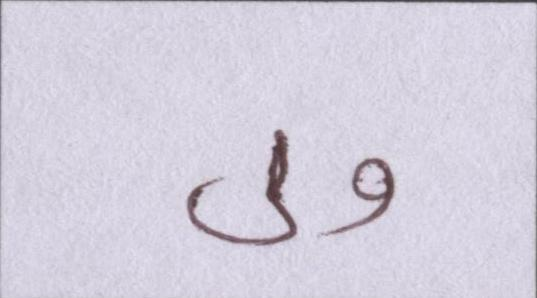

gt='رنگیں'  pred='ر فکین'  size=(887, 298)


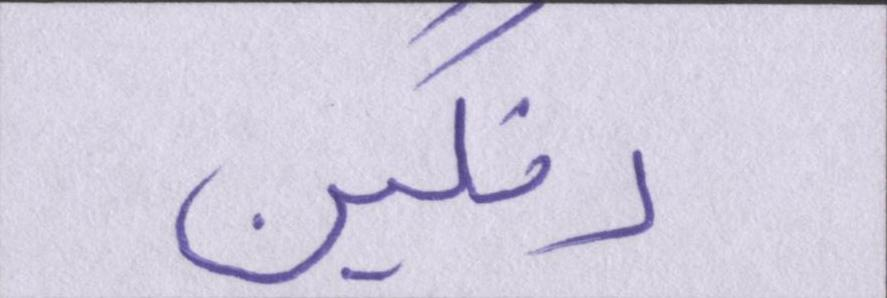

gt='اندر،'  pred='اندر'  size=(888, 303)


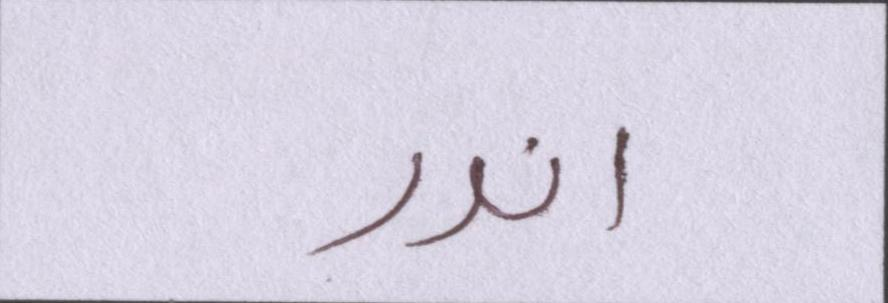

gt='لباس'  pred='لبا میں'  size=(714, 298)


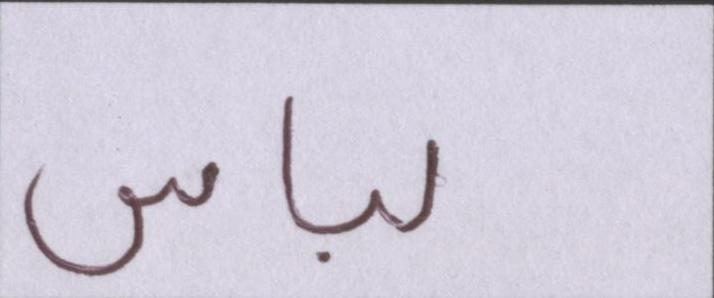

gt='ورم'  pred='و ارم'  size=(536, 300)


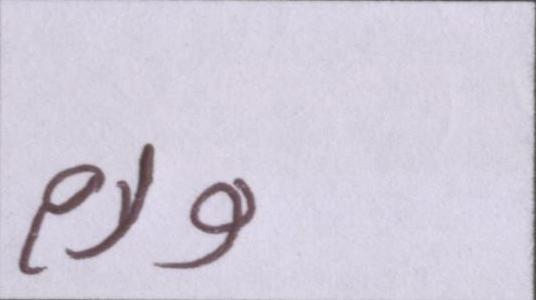

gt='افسوں'  pred='افسوس'  size=(892, 301)


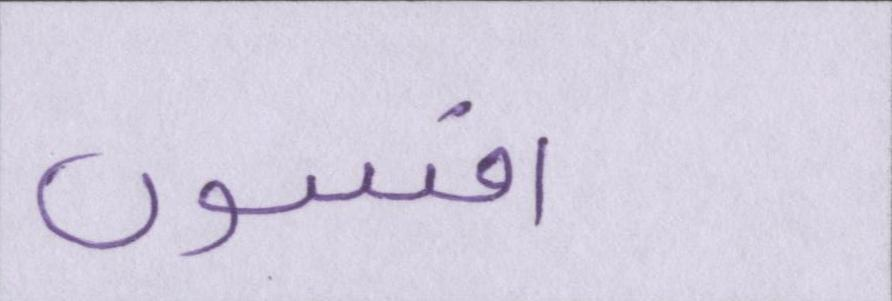

gt='رضوی'  pred='رضوی)'  size=(715, 300)


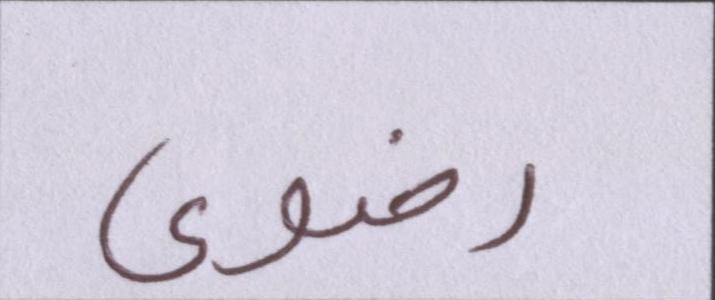

gt='محمد'  pred='محمود'  size=(715, 297)


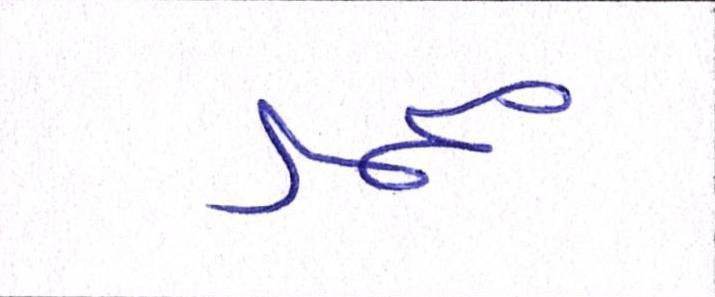

gt='اکبر'  pred='اعیر'  size=(714, 300)


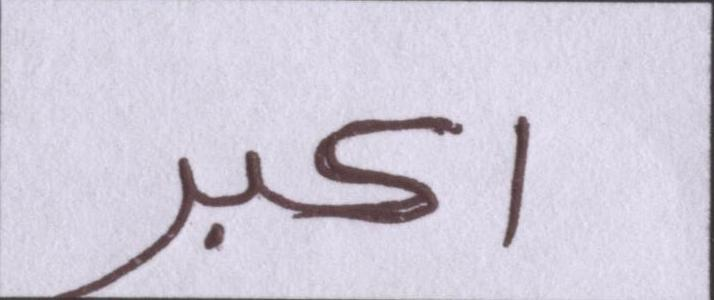

gt='داشیچیاو'  pred='د ا شیعہ و'  size=(1427, 303)


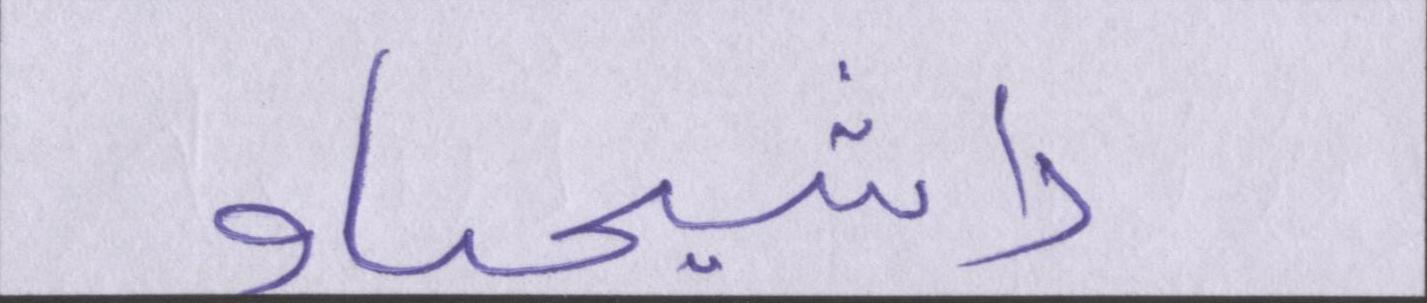

In [16]:
import pandas as pd
from PIL import Image

df = pd.read_csv("qwen_ocr_predictions.csv")
wrong = df[df["exact_match"] == 0].head(10)

for _, row in wrong.iterrows():
    img = Image.open(row["image_path"])
    print(f"gt={row['ground_truth']!r}  pred={row['prediction_normalized']!r}  size={img.size}")
    display(img)

**Generating word samples using DiffusionRec and testing qwen on them**

In [22]:
!python generate_word_samples.py --mode random \
  --ckpt_dir .../word_level_model/models \
  --test_gt_folder .../val/gt \
  --out_dir generated_samples --n_words 200 --seed 42


!python inference/active/qwen_eval.py \
  --checkpoint /content/DiffusionRec_Research/qwen_model \
  --manifest generated_samples/manifest.csv \
  --max_samples 200

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading CANINE text encoder...
tokenizer_config.json: 100% 892/892 [00:00<00:00, 4.71MB/s]
special_tokens_map.json: 100% 657/657 [00:00<00:00, 3.25MB/s]
config.json: 100% 698/698 [00:00<00:00, 2.48MB/s]
model.safetensors: 100% 528M/528M [00:09<00:00, 54.3MB/s]
Loading weights: 100% 246/246 [00:00<00:00, 990.55it/s, Materializing param=projection.conv.weight] 
CanineModel LOAD REPORT from: google/canine-c
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading VAE...
/usr/local/lib

**Computing FID on generated samples**

In [24]:
!pip install pytorch-fid
!python inference/active/compute_fid.py \
    --real_dir /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images \
    --generated_dir generated_samples \
    --batch_size 50

Using device: cuda
Preprocessing 13906 images from /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images -> /tmp/tmpgzdeglee/real (aspect-preserving, canvas=(64, 256))
100% 13906/13906 [01:32<00:00, 150.97it/s]
Preprocessing 200 images from generated_samples -> /tmp/tmpgzdeglee/gen (aspect-preserving, canvas=(64, 256))
100% 200/200 [00:01<00:00, 169.23it/s]
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 212MB/s]
100% 279/279 [00:59<00:00,  4.72it/s]
100% 4/4 [00:00<00:00,  4.22it/s]

FID: 65.08

For reference, the paper reports (Table 1, word-level):
  DiffusionRec (theirs): FID 19.35
  OneDM baseline:        FID 99.6
  DiffBrush baseline:    FID 111


**Eyeballing what was fed to the diffusionRec and what it came up with**

In [26]:
!python inference/active/build_comparison_grid.py \
  --generated_manifest generated_samples/manifest.csv \
  --real_gt_folder /content/DiffusionRec_Research/Urdu_Word_Dataset/val/gt_txt \
  --real_images_folder /content/DiffusionRec_Research/Urdu_Word_Dataset/val/images \
  --out_dir comparison_grid \
  --n_pairs 10

Indexing real images by ground-truth word...
Indexed 6970 unique real words
Loaded 200 generated samples
200/200 generated words have a matching real image with the same ground truth

Saved contact sheet: comparison_grid/comparison_sheet.png
(10 pairs, matched by shared ground-truth word)


#Diagnosing dataset noise and model inheritance by canonical distancing againt printed urdu text using urdu_font.ttf

**Checking printed text rendering from urdu_font.ttf**

In [35]:
!pip install arabic-reshaper
!pip install python-bidi
!python inference/Dataset_Quality_check/canonical_distance.py --preview_word "کون" --font_path tokenizer_assets/urdu_font.ttf

Saved canonical_preview.png for word: کون
LOOK AT THIS IMAGE before running the full manifest. It should show
properly joined, connected Nastaliq-style letterforms -- not floating,
disconnected individual characters. If it looks wrong, do not proceed.


In [32]:
!grep -n "font_path" /content/DiffusionRec_Research/inference/Dataset_Quality_check/canonical_distance.py

17:  python canonical_distance.py --preview_word "کون" --font_path urdu_font.ttf
23:    --font_path urdu_font.ttf \
29:    --font_path urdu_font.ttf \
90:    ap.add_argument("--font_path", default="urdu_font.ttf")
100:    font = ImageFont.truetype(args.font_path, args.font_size)


In [36]:
!ls -la tokenizer_assets/urdu_font.ttf

-rw-r--r-- 1 root root 529980 Jul 30 04:41 tokenizer_assets/urdu_font.ttf


In [37]:
from PIL import Image, ImageDraw, ImageFont

font = ImageFont.truetype("tokenizer_assets/urdu_font.ttf", 40)
img = Image.new("RGB", (200, 100), (255, 255, 255))
draw = ImageDraw.Draw(img)
draw.text((10, 10), "کون", fill=(0, 0, 0), font=font)
img.save("test_render.png")

In [38]:
import arabic_reshaper
from bidi.algorithm import get_display

word = "کون"
reshaped = arabic_reshaper.reshape(word)
display_text = get_display(reshaped)
print(repr(reshaped))
print(repr(display_text))

'ﮐﻮﻥ'
'ﻥﻮﮐ'


In [5]:
from PIL import features
print(features.check('raqm'))

True
